# Assignment 2 - Abramov Aleksandr. Question 3

Implement a single-layer perceptron with sigmoid activation to learn AND and OR logic
gates using gradient descent. Manually compute and verify one step of back-propagation for a sample
input, then experiment with learning rates (0.1, 0.5, 1.0) to observe their effect on convergence speed and
stability. Explain why this architecture fails for XOR despite tuning the learning rate. 

First, let's derive the formulas for gradients and manually compute one step of back-propagation. For simplicity, consider one object in the batch. Let:
- $y$ - target variable
- $p$ - prediction
- $X = (x_1, x_2)$ - feature vector
- $W = (w_1, w_2)^T$, $b$ - parameters of the single-layer perceptron
$$
\begin{cases}
    L = - y \log(p) - (1 - y) \log(1 - p) \\
    p = \sigma(m) \\
    m = X W + b \\
\end{cases}
$$
$$
\begin{cases}
    dL / dp = \dfrac{-y}{p} + \dfrac{1 - y}{1 - p} \\
    dp / dm = \sigma(m) \cdot (1 - \sigma(m)) \\
    dm / dw = X^T \\
    dm / db = 1 \\
\end{cases}
$$
For training, we need $dL / dw$ and $dL / db$. Let's compute those using the chain rule following the ideas of back-propagation:
$$\dfrac{dL}{dw} = \dfrac{dL}{dp} \cdot \dfrac{dp}{dw} = \dfrac{dL}{dp} \cdot \dfrac{dp}{dm} \cdot \dfrac{dm}{dw} = \left(\dfrac{-y}{p} + \dfrac{1 - y}{1 - p}\right) \left(\sigma(m) \cdot (1 - \sigma(m))\right) X^T$$
Similarly,
$$\dfrac{dL}{db} = \dfrac{dL}{dp} \cdot \dfrac{dp}{dm} \cdot \dfrac{dm}{db} = \left(\dfrac{-y}{p} + \dfrac{1 - y}{1 - p}\right) \left(\sigma(m) \cdot (1 - \sigma(m))\right)$$

For verification, let's consider a sample input:
$$
\begin{cases}
    x = (1, 1) \\
    y = 1 \\
    w = (-3, 5)^T \\
    b = -2 \\
\end{cases}
$$
With this,
$$
\begin{cases}
    m = -3 + 5 - 2 = 0 \\
    p = \sigma(0) = \dfrac{1}{2} \\
    L = - \log(1/2) = \log(2) \approx 0.69 \\
\end{cases}
$$
$$
\begin{cases}
    dL / dp = \dfrac{-1}{1 / 2} + \dfrac{1 - 1}{1 - 1 / 2} = -2 \\
    dp / dm = \dfrac{1}{2} (1 - \dfrac{1}{2}) = \dfrac{1}{4} \\
    dm / dw = (1, 1)^T \\
    dm / db = 1 \\
\end{cases}
$$
$$
\begin{cases}
    dL / dw = -2 \cdot \dfrac{1}{2} \cdot (1 - \dfrac{1}{2}) \cdot (1, 1)^T = (-0.5, -0.5)^T \\
    dL / db = -2 \cdot \dfrac{1}{2} \cdot (1 - \dfrac{1}{2}) = -0.5 \\
\end{cases}
$$

In [1]:
import typing
from __future__ import annotations

import numpy

# A wrapper aroung numpy arrays with back-propagation support
class Matrix:
    def __init__(
      self,
      value: numpy.ndarray,
      grad_func: typing.Optional[typing.Callable[[Matrix], None]]=None
    ):
        self.value = numpy.array(value)
        self.grad_func = grad_func
        self.grad = None

    def zero_grad(self):
        self.grad_func = None
        self._zero_grad()
        
    def _zero_grad(self):
        self.grad = Matrix(numpy.zeros_like(self.value))
        
    def backward(self, upstream_grad: Matrix = None):
        if upstream_grad is None:
            # This is the root node: dL/dL = 1
            upstream_grad = Matrix(numpy.ones_like(self.value))

        if upstream_grad.shape() != self.shape():
            # Broadcasting had happened, and we need to handle it.
            assert (
                len(self.shape()) == 0
            ), "Only broadcasting from a number is supported"
            upstream_grad = Matrix(upstream_grad.value.sum())

        if self.grad is None:
            self._zero_grad()
        self.grad += upstream_grad # Accumulate gradient
        if self.grad_func is not None:
            # Propagate gradient to parents
            self.grad_func(upstream_grad)

    def __neg__(self):
        # Negation: (-f)' = -f'
        def grad_func(upstream_grad: Matrix = None):
            self.backward(-upstream_grad)
        return Matrix(-self.value, grad_func)

    def __add__(self, other: Matrix) -> Matrix:
        # Addition: (a + b)' = a' + b'
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad)
            other.backward(upstream_grad)
        return Matrix(self.value + other.value, grad_func)

    def __sub__(self, other: Matrix) -> Matrix:
        # Subtraction: (a - b)' = a' - b'
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad)
            other.backward(-upstream_grad)
        return Matrix(self.value - other.value, grad_func)
    
    def __mul__(self, other: Matrix) -> Matrix:
        # Element-wise multiplication: (ab)' = a'b + b'a
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad * other)
            other.backward(upstream_grad * self)
        return Matrix(self.value * other.value, grad_func)
    
    def __truediv__(self, other: Matrix) -> Matrix:
        # Element-wise division:
        # (a/b)' = (a'b - b'a) / (b^2) = (a' / b) - (b'a / b^2)
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad / other)
            other.backward(-upstream_grad * self / (other ** 2))
        return Matrix(self.value / other.value, grad_func)
    
    def __matmul__(self, other: Matrix) -> Matrix:
        # Matrix multiplication: (A @ B)' = A' @ B^T + A^T @ B'
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad @ other.transpose())
            other.backward(self.transpose() @ upstream_grad)
        return Matrix(self.value @ other.value, grad_func)
    
    def __pow__(self, power: int) -> Matrix:
        # Element-wise power: (A^n)' = n * A ^ (n-1) * A'
        def grad_func(upstream_grad: Matrix = None):
            power_full = Matrix(numpy.full_like(upstream_grad, power))
            d_self = power_full * (self ** (power - 1))
            self.backward(upstream_grad * d_self)
        return Matrix(self.value ** power, grad_func)

    def transpose(self):
        # Transposing: (A^T)' = (A')^T
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad.transpose())
        return Matrix(self.value.transpose(), grad_func)
    
    def exp(self):
        # Element-wise exponentiation: (e^A)' = A' * e^A
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad * self.exp())
        return Matrix(numpy.exp(self.value), grad_func)
    
    def log(self):
        # Element-wise logarithm: (logA)' = A' / A
        def grad_func(upstream_grad: Matrix = None):
            self.backward(upstream_grad / self)
        return Matrix(numpy.log(self.value), grad_func)
    
    def sum(self):
        def grad_func(upstream_grad: Matrix = None):
            grad = numpy.full_like(self.value, upstream_grad.value)
            self.backward(Matrix(grad))
        return Matrix(numpy.sum(self.value), grad_func)
    
    def __len__(self):
        return len(self.value)
    
    def shape(self):
        return self.value.shape

    def __repr__(self):
        return "Matrix" + self.value.__repr__()[len("array"):]
    
def sigmoid(data: Matrix):
    return Matrix(1) / (Matrix(1) + (-data).exp())

def bce_loss(y_true: Matrix, y_pred: Matrix):
    positives = y_true * y_pred.log()
    negatives = (Matrix(1) - y_true) * (Matrix(1) - y_pred).log()
    loss = -(positives + negatives)
    return loss.sum() / Matrix(len(y_true))

Let's verify the result on the sample input considered previously.

In [2]:
def test_my():
    w = Matrix([ [-3], [5] ])
    x = Matrix([ [ 1, 1 ] ])
    b = Matrix(-2)
    y = Matrix([[1]])
    loss = bce_loss(y, sigmoid(x @ w + b))
    loss.backward()
    print(w.grad)
    print(b.grad)

def test_torch():
    # For verification, let's compare the output with the one from torch
    import torch
    w = torch.tensor([[-3], [5]], dtype=float, requires_grad=True)
    x = torch.tensor([[ 1, 1 ]], dtype=float, requires_grad=True)
    b = torch.tensor(-2, dtype=float, requires_grad=True)
    y = torch.tensor([[1]], dtype=float, requires_grad=True)
    loss = torch.nn.functional.binary_cross_entropy(
        torch.nn.functional.sigmoid(x @ w + b), y
    )
    loss.backward()
    print(w.grad)
    print(b.grad)

test_my(), test_torch()

Matrix([[-0.5],
       [-0.5]])
Matrix(-0.5)
tensor([[-0.5000],
        [-0.5000]], dtype=torch.float64)
tensor(-0.5000, dtype=torch.float64)


(None, None)

The results match both each other and the theoretical, manual computation. Let's proceed to implementing the perceptron and running the experiments.

In [3]:
import typing

import tqdm
import numpy

class Perceptron:
    def __init__(self, n_features: int = 2):
        numpy.random.seed(42)
        self.W = Matrix(numpy.random.randn(n_features, 1) / 2)
        self.b = Matrix(numpy.random.randn() / 2)

    def predict(self, X: Matrix) -> Matrix:
        return sigmoid(X @ self.W + self.b)
        
    def train(
        self,
        X: Matrix,
        y: Matrix,
        epochs: int = 500,
        lr: float = 2.5,
        desc: typing.Optional[str] = None
    ) -> typing.Tuple[typing.List[float], typing.List[float]]:
        pbar = tqdm.trange(epochs, desc = desc)
        loss_history, accuracy_history = [], []
        for _ in pbar:
            pred_logits = self.predict(X) # Froward pass
            loss = bce_loss(y, pred_logits) # Calculate loss
            loss.backward() # Compute gradients
            # Update parameters
            self.W -= Matrix(lr) * self.W.grad
            self.b -= Matrix(lr) * self.b.grad
            # Zero gradients for next iteration
            self.W.zero_grad()
            self.b.zero_grad()

            loss_history.append(loss.value)
            accuracy_history.append(
                numpy.mean((pred_logits.value > 0.5) == y.value)
            )
            pbar.set_postfix({
                'Loss': loss_history[-1],
                'Accuracy': accuracy_history[-1]
            })

        print("Prediction: ", self.predict(X).value.tolist())
        return loss_history, accuracy_history

Now let's use this implementation to solve the AND, OR, and XOR gate problems.

In [4]:
import matplotlib.figure
import matplotlib.pyplot as plt

def try_and_show(
    X: Matrix, y: Matrix, title: str, epochs: int = 500
) -> matplotlib.figure.Figure:
    fig, axes = plt.subplots(1, 2, figsize = (20, 3))
    fig.suptitle(title)

    for lr in [0.1, 0.5, 1.0]:
        model = Perceptron()
        loss_history, accuracy_history = model.train(
            X, y, epochs, lr, f"Learning rate {lr}"
        )
        print("W = ", model.W.value.tolist())
        print("b = ", model.b.value.tolist())
        axes[0].plot(loss_history, label = f"Learning rate: {lr}")
        axes[1].plot(accuracy_history, label = f"Learning rate: {lr}")
        
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha = 0.3)
        ax.legend()
    axes[0].set_title("Loss")
    axes[0].set_ylabel("Binary cross-entropy loss")
    axes[1].set_title("Accuracy")
    axes[1].set_ylabel("Accuracy")
    fig.tight_layout()

In [5]:
# Training data: same features, different target variables as requested in the task
X = Matrix([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = Matrix([[0], [0], [0], [1]])
y_or = Matrix([[0], [1], [1], [1]])
y_xor = Matrix([[0], [1], [1], [0]])

Learning rate 0.1: 100%|██████████| 500/500 [00:01<00:00, 454.56it/s, Loss=0.23044441733108564, Accuracy=1]   


Prediction:  [[0.03603929937005922], [0.21637811763033843], [0.2206674817829506], [0.6765059450474911]]
W =  [[2.024659688283389], [1.9995413453271427]]
b =  -3.286440534589408


Learning rate 0.5: 100%|██████████| 500/500 [00:00<00:00, 503.50it/s, Loss=0.0670444432490581, Accuracy=1] 


Prediction:  [[0.0007704209587680041], [0.07488288780599826], [0.07489073721084062], [0.894723658890772]]
W =  [[4.653921136575802], [4.653807834853457]]
b =  -7.167802774918164


Learning rate 1.0: 100%|██████████| 500/500 [00:00<00:00, 537.30it/s, Loss=0.03471114751866859, Accuracy=1] 


Prediction:  [[0.00010114203511387154], [0.03975440017219717], [0.039754565843934345], [0.9442730145179629]]
W =  [[6.014419379750611], [6.01441503984756]]
b =  -9.198883593613806


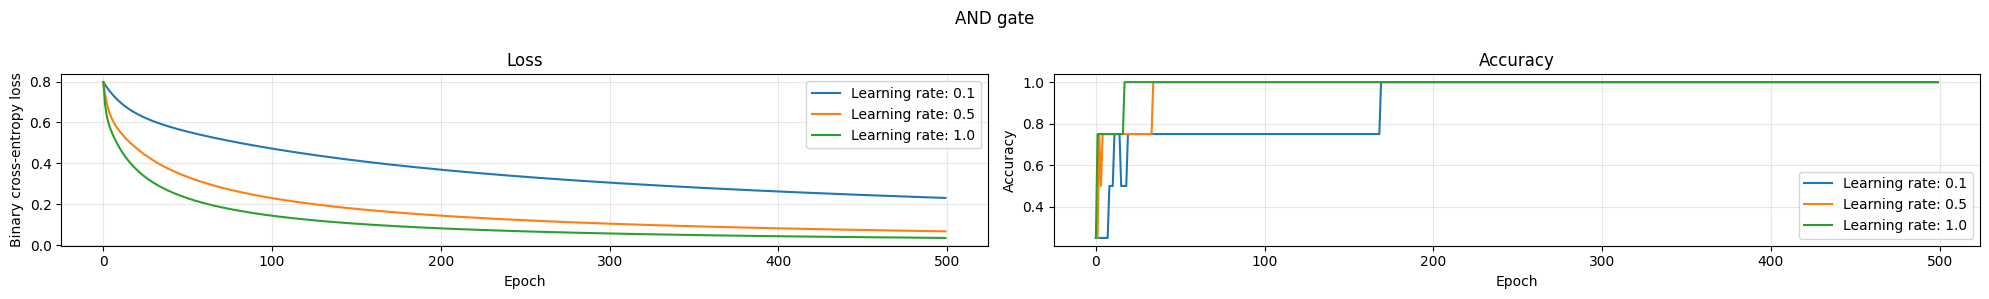

In [6]:
try_and_show(X, y_and, "AND gate")

Learning rate 0.1: 100%|██████████| 500/500 [00:01<00:00, 474.52it/s, Loss=0.15857555383651042, Accuracy=1]   


Prediction:  [[0.3154583766096736], [0.8810789343312572], [0.88702209746178], [0.9921400779282566]]
W =  [[2.8354003541507162], [2.777409965296789]]
b =  -0.7747227063979999


Learning rate 0.5: 100%|██████████| 500/500 [00:01<00:00, 443.56it/s, Loss=0.03797133142775375, Accuracy=1] 


Prediction:  [[0.08188515662784154], [0.9674566048135373], [0.9675718403262965], [0.9998994609081453]]
W =  [[5.8127672524860365], [5.809100883615749]]
b =  -2.41700474783033


Learning rate 1.0: 100%|██████████| 500/500 [00:00<00:00, 607.64it/s, Loss=0.018855511246892408, Accuracy=1]


Prediction:  [[0.04123401368245163], [0.9835550665179993], [0.98356952166111], [0.9999879879712936]]
W =  [[7.238433814064997], [7.237539727959451]]
b =  -3.1463835360948416


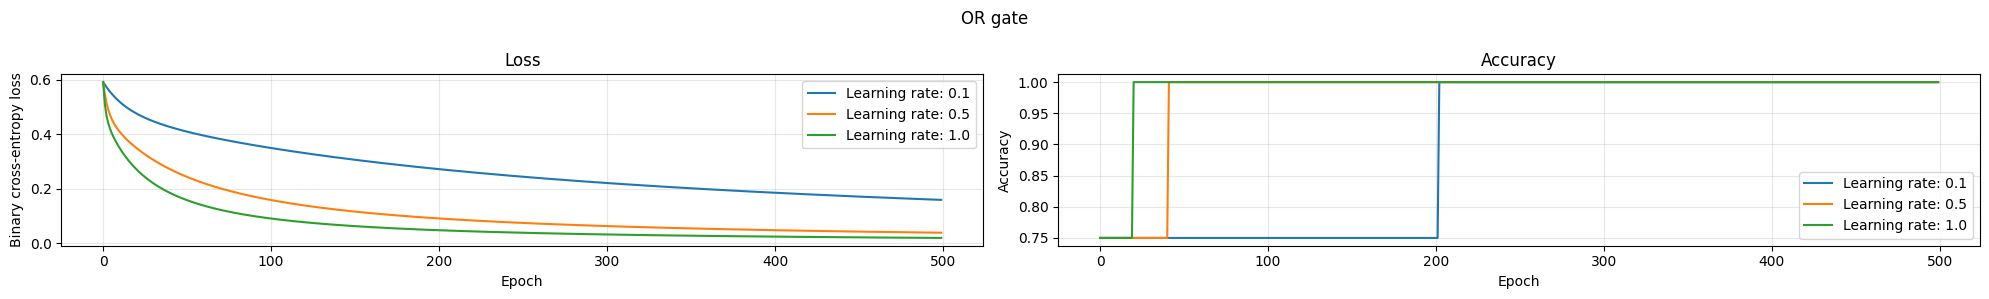

In [7]:
try_and_show(X, y_or, "OR gate")

Learning rate 0.1: 100%|██████████| 500/500 [00:01<00:00, 471.96it/s, Loss=0.6931550144184717, Accuracy=0.5]


Prediction:  [[0.50249975845335], [0.49865760874606746], [0.502126970136884], [0.4982848159344788]]
W =  [[-0.0014911852561794187], [-0.015368695040993592]]
b =  0.009999117123830462


Learning rate 0.5: 100%|██████████| 500/500 [00:00<00:00, 667.92it/s, Loss=0.693147180560572, Accuracy=0.75] 


Prediction:  [[0.5000008901979343], [0.5000001346087628], [0.5000001447881718], [0.49999938919900044]]
W =  [[-2.981639049708107e-06], [-3.0223566856862893e-06]]
b =  3.560791736967328e-06


Learning rate 1.0: 100%|██████████| 500/500 [00:01<00:00, 484.87it/s, Loss=0.6931471805599453, Accuracy=0.75]


Prediction:  [[0.5000000000363468], [0.5000000000057035], [0.5000000000057043], [0.49999999997506106]]
W =  [[-1.2257003745297368e-10], [-1.2257311832186701e-10]]
b =  1.4538709125488936e-10


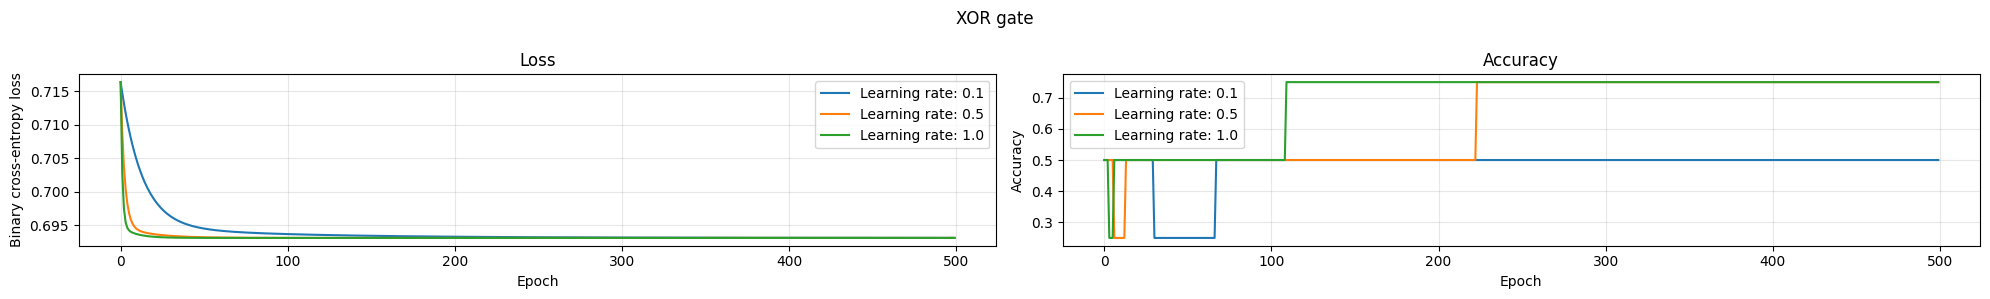

In [8]:
try_and_show(X, y_xor, "XOR gate")

A one-layer network is defined as $y = \sigma(Wx + b) = \sigma(w_1 x_1 + w_2 x_2 + b)$. So, the predictions for each input are as follows:
- $x_1 = 0, x_2 = 0 \Rightarrow y = \sigma(b), \text{target} = 0$
- $x_1 = 1, x_2 = 0 \Rightarrow y = \sigma(w_1 + b), \text{target} = 1$
- $x_1 = 0, x_2 = 1 \Rightarrow y = \sigma(w_2 + b), \text{target} = 1$
- $x_1 = 1, x_2 = 1 \Rightarrow y = \sigma(w_1 + w_2 + b), \text{target} = 0$

Suppose the object is classified as positive if $y \gt t$, where $t$ is some threshold. Let's consider the three problems in these terms.

### AND gate

Since $\sigma(x)$ is monotonous, solving the problem perfectly requires the following conditions to hold for some threshold $q = \log\left(\dfrac{1 - t}{t}\right)$:
$$
\begin{cases}
    b \le q & (1) \\
    w_1 + b \le q & (2) \\
    w_2 + b \le q & (3) \\
    w_1 + w_2 + b \gt q & (4) \\
\end{cases}
$$
One can easily verify that $w_1 = 1$, $w_2 = 1$, $b = 0$, $q = 1.5$ provide the needed separation of the data points, and lead to perfect accuracy, which is expected for this linearly-separable problem.

Indeed, for the AND gate problem, the perceptron converged to the perfect prediction with all three choices of the learning rate. Expectedly, the higher the learning rate, the faster the model converged to the needed result. Interestingly, no obvious discrepancies in the stability of the training process can be highlighted, which is due to the simplicity of the model and the dataset: the gradient landscape of the perceptron has one global minima and no local minimas, which makes it easy to find the optimal solution. Generally, one would expect bigger learning rates to introduce issues with stability.

### OR gate

Similar results have been obtained for the OR gate problem. To solve this task, the model parameters should satisfy the following conditions:
$$
\begin{cases}
    b \le q & (1) \\
    w_1 + b \gt q & (2) \\
    w_2 + b \gt q & (3) \\
    w_1 + w_2 + b \gt q & (4) \\
\end{cases}
$$
Since the OR gate problem is also linearly-separable, one would expect the perceptron to solve it perfectly as well. Indeed, $w_1 = 1$, $w_2 = 1$, $b = 0$, $q = 0.5$ provide the necessary result.

In practice, the model converged successfully with all three choices of the learning rate with similar patterns as before: the higher the learning rate, the faster the convergence, and no obvious stability issues have been observed for either of the choices.

### XOR gate

Finally, the XOR gate problem requires the following conditions:
$$
\begin{cases}
    b \le q & (1) \\
    w_1 + b \gt q & (2) \\
    w_2 + b \gt q & (3) \\
    w_1 + w_2 + b \le q & (4) \\
\end{cases}
$$
As shown in the previous assigment, there exist no values of $w_1$, $w_2$, and $b$ that satisfy all four conditions. From $(2)$ and $(3)$, $w_1 + w_2 + 2b \gt 2q$. Accounting for $(1)$, $w_1 + w_2 + 2b + q \gt 2q + b$. Thus, $w_1 + w_2 + b \gt q$, which is a contradiction to $(4)$. Therefore, the single-layer architecture will inevitably fail to solve this non-linear problem despite the learning rate, and the best possible accuracy it can achieve is $75\%$.

Nonetheless, as demonstrated in the experiment, increasing the learning rate still leads to faster convergence, yet neither of the three choices led to perfect accuracy. Moreover, only training with learning rates of $0.5$ and $1.0$ led to a $75\%$ accuracy, while the learning rate of $0.1$ achieved only $50\%$.